# Regressão Linear com Várias Variáveis
Vamos considerar o seguinte modelo:
$$
    y = A \beta + \epsilon      \\
    \epsilon \sim \mathcal{N}(0, \sigma^2 I)
$$

é possível mostrar que os estimadores de máxima verossimilhança de $\beta$ e $\sigma^2$:
$$
    \hat{\beta} = (X^\mathsf{T} X)^{-1}X^\mathsf{T} y       \\
    \hat{\sigma}^2 = \frac{1}{n} (y - X \hat{\beta})^\mathsf{T} (y - X \hat{\beta})
$$

com algumas contas a mais, podemos também mostrar que:
$$
    \hat{\beta} \sim \mathcal{N} (\beta, \sigma^2 (X^\mathsf{T} X)^{-1})        \\
    I(\beta) = \frac{X^\mathsf{T}X}{\sigma^2}
$$

onde $I(\beta)$ é a informação de fisher de $\beta$

Vamos fazer uma análise do teste padronizado entre $n$ crianças, onde foram medidos o coeficiente de inteligência da mãe e se ela completou o ensino médio. Então queremos saber como a habilidade inata da criança (provavelmente influenciada pelo QI da mãe) e sua condição socioeconômica afetam seus resultados

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [46]:
kidiq = pd.read_csv('../data/kidiq.csv')

In [47]:
kidiq.head()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
0,65,1,121.117529,4,27
1,98,1,89.361882,4,25
2,85,1,115.443165,4,27
3,83,1,99.449639,3,25
4,115,1,92.745710,4,27


In [48]:
kidiq.describe()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
count,434.000000,434.000000,434.000000,434.000000,434.000000
mean,86.797235,0.785714,100.000000,2.896313,22.785714
std,20.410688,0.410799,15.000000,1.181394,2.701070
min,20.000000,0.000000,71.037405,1.000000,17.000000
25%,74.000000,1.000000,88.660321,2.000000,21.000000
50%,90.000000,1.000000,97.915254,3.000000,23.000000
75%,102.000000,1.000000,110.272742,4.000000,25.000000
max,144.000000,1.000000,138.893106,4.000000,29.000000


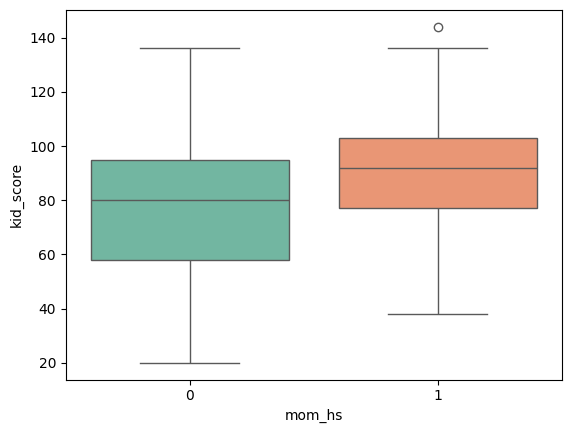

In [49]:
sns.boxplot(x='mom_hs', y='kid_score', data=kidiq, hue='mom_hs', palette='Set2', legend=False)
plt.show()

## Perguntas
De posse desses dados, podemos nos fazer várias perguntas sobre associações nos dados. Por exemplo, queremos saber se o QI da mãe tem alguma associação (leia-se: capacidade preditiva) com as notas (scores) da criança. Além disso, essa associação é mediada pelo nível educacional da mãe? Como o fato de que a mãe trabalha fora impacta a variável resposta (na presença das outras covariáveis relevantes)?

Para isso, vamos imaginar um modelo saturado:
$$
    \text{kid\_score} = \beta_0 + \beta_{\text{hs}} \text{mom\_hs} + \beta_{\text{iq}} \text{mom\_iq} + \beta_{\text{hs:iq}} \text{mom\_hs} * \text{mom\_iq} + \epsilon
$$

primeiro, vamos analisar o modelo quando $\beta_{\text{hs}} = \beta_{\text{hs:iq}} = 0$, ou seja, vamos assumir, por enquanto, que o QI da mãe não afeta no resultado da criança
$$
    \text{kid\_score} = \beta_0 + \beta_{\text{hs}} \text{mom\_hs} + \epsilon
$$

In [50]:
modelo = smf.ols('kid_score ~ mom_hs', data=kidiq).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              kid_score   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     25.69
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           5.96e-07
Time:                        13:48:04   Log-Likelihood:                -1911.8
No. Observations:                 434   AIC:                             3828.
Df Residuals:                     432   BIC:                             3836.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     77.5484      2.059     37.670      0.0

Pelo saída do comando anterior, nós obtivemos que:
$$
    \beta_0 = 77.54     \\
    \beta_{\text{hs}} = 11.77
$$

ou seja, a média de scores é $77.54$ e, quando a mãe da criança tem escolaridade, ela tem uma pontuação $\approx 11.77$ maior

Vale ressaltar também sobre os testes que o modelo realizou (colunas _t_ e _P>|t|_). Esses testes são com relação às hipóteses:
$$
    H_0: \beta_j = 0 \space (\beta_i = 0 \space \forall i \neq j) \\
    H_1: \beta_j \neq 1
$$
onde as estatísticas de teste são dadas por:
$$
    \frac{\hat{\beta_j} - \beta}{\sqrt{\hat{\sigma}^2 (X^\mathsf{T} X)_{jj}}} \sim t_{n - p}
$$
onde $p$ é o número de parâmetros. Ou seja, analisando o $\beta_{\text{hs}}$, ele acha que:
$$
    \mathbb{P}(|T| \ge 5.069|H_0 \space \text{é verdadeira}) \approx 0
$$

logo, como esse número é muito baixo, nós descartamos $H_0$. A última parte é o intervalo de confiança, onde ele diz que o valor verdadeiro de $\beta_{\text{hs}}$ está entre $(7.207, 16.336)$ com $95%$ de certeza

Agora vamos analisar o seguinte modelo:
$$
    \text{kid\_score} = \beta_0 +  \beta_{\text{iq}} \text{mom\_iq} + \epsilon
$$

onde estamos assumindo que a escolaridade da mãe não tem nenhum efeito na pontuação do moleque

In [51]:
modelo = smf.ols('kid_score ~ mom_iq', data=kidiq).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              kid_score   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     108.6
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           7.66e-23
Time:                        13:48:04   Log-Likelihood:                -1875.6
No. Observations:                 434   AIC:                             3755.
Df Residuals:                     432   BIC:                             3763.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.7998      5.917      4.360      0.0

Mas se pararmos para pensar, fica dificil interpretar o intercepto nesse cenário, já que seria uma análise de se o QI da mãe fosse 0, o que é bem longe da realidade. Para interpretarmos melhor, podemos refazer a análise centrando o QI na média

In [52]:
kidiq['mom_iq'] = kidiq['mom_iq'] - kidiq['mom_iq'].mean()
modelo = smf.ols('kid_score ~ mom_iq', data=kidiq).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              kid_score   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     108.6
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           7.66e-23
Time:                        13:48:04   Log-Likelihood:                -1875.6
No. Observations:                 434   AIC:                             3755.
Df Residuals:                     432   BIC:                             3763.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     86.7972      0.877     98.993      0.0

Agora da pra interpretar bem! Quando o QI da mãe está dentro da média, a nota esperada do aluno é de aproximadamente 86 pontos. E também vemos que para cada ponto de QI da mãe, a nota do aluno aumenta aproximadamente $0.61$